In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kX0RjUlt2tVQzkpKm4ZV")
project = rf.workspace("hemavardhan").project("landmines-detection-dataset-sewvx")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 139.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Landmines-detection-dataset-1 in yolov8:: 100%|██████████| 2400/2400 [00:00<00:00, 6249.54it/s]


In [ ]:
!pip install -U ultralytics

from ultralytics import YOLO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")


In [ ]:
results = model.train(
    data="/content/Landmines-detection-dataset-1/data.yaml",  # dataset yaml
    epochs=50,          # adjust based on dataset size
    imgsz=640,          # image size
    batch=16,           # batch size
    name="yolov8_landmine",
    project="/content/runs/train",
    workers=4
)


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Landmines-detection-dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_landmine, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

In [ ]:
# Load trained YOLOv8 weights
model = YOLO("/content/runs/train/yolov8_landmine/weights/best.pt")

# Evaluate on validation or test set
metrics = model.val(
    data="/content/Landmines-detection-dataset-1/data.yaml",
    split='test',      # or 'val'
    plots=True         # optional: generates PR curves, confusion matrix
)

# Print metrics
print(metrics)


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 687.1±591.6 MB/s, size: 23.3 KB)
val: Scanning /content/Landmines-detection-dataset-1/test/labels... 118 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 2.3Kit/s 0.1s
val: New cache created: /content/Landmines-detection-dataset-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7it/s 3.0s
                   all        118        121      0.974      0.945      0.981      0.641
Speed: 4.7ms preprocess, 7.7ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionM


image 1/1 /content/Landmines-detection-dataset-1/test/images/1013_Zone_7_Mine_5cm_depth__2-0m_TemperatureInCenter__45A-C_jpg.rf.7a1a043d43bcd53856ec6ec52221a104.jpg: 448x640 1 landmines, 48.7ms
Speed: 6.5ms preprocess, 48.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


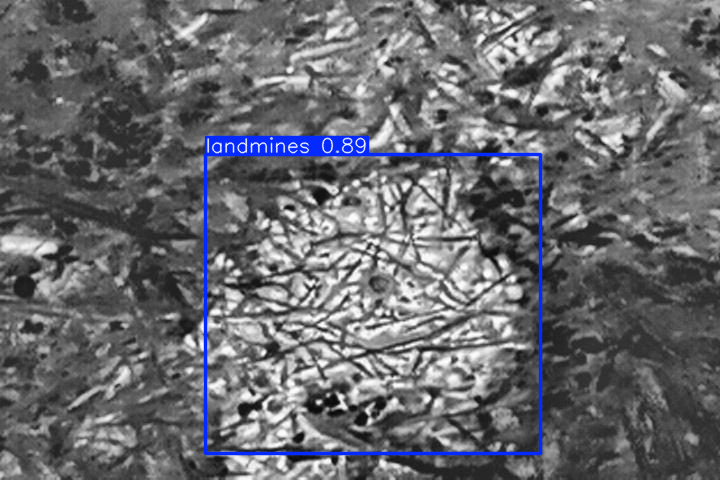

In [ ]:
# Single image inference
results = model("/content/Landmines-detection-dataset-1/test/images/1013_Zone_7_Mine_5cm_depth__2-0m_TemperatureInCenter__45A-C_jpg.rf.7a1a043d43bcd53856ec6ec52221a104.jpg")

# Show first result
results[0].show()
